# Data validation and duplicate handling
**Assigned member:** Punsara P. S. | **IT number:** IT25102224

**Group:** 26-MTR-SE2030-14 | **Dataset:** Letter Recognition

This notebook includes implementation, visible outputs, EDA, interpretation, and viva preparation. Run all cells and explain the decisions in your own words.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Works when launched from the project root or the notebooks directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "pipeline.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "pipeline.py").exists(), "Start Jupyter inside the extracted project folder."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.pipeline import (FEATURES, SEED, load_raw, audit_and_clean, split_data,
                          outlier_audit, fit_transforms, verify, run)
raw = load_raw(ROOT)
clean, audit, removed = audit_and_clean(raw)
splits = split_data(clean)
train = splits["train"]
print("Raw:", raw.shape, "Clean:", clean.shape)
print("Partitions:", {name: len(part) for name, part in splits.items()})


Raw: (20000, 17) Clean: (18668, 17)
Partitions: {'train': 13067, 'validation': 2800, 'test': 2801}


## Shared inputs
The integrated pipeline generates the common plot artifacts. If they are absent, the following cell regenerates them. This notebook's technique implementation below remains independently executable.

In [2]:
if not (ROOT / "results/eda_visualizations/10_outlier_rates.png").exists():
    run(ROOT)

## Technique and justification
Check completeness, column types, A-Z labels, integer values, and the documented 0-15 bounds. Remove exact repeated records before partitioning. No artificial missing values are inserted, and no unnecessary imputation is performed. Quantization can map different images to the same vector; deduplication is an explicit evaluation choice.

In [3]:
missing = raw.isna().sum()
duplicate_mask = raw.duplicated(keep="first")
clean_local = raw.loc[~duplicate_mask].copy()
assert raw.letter.isin(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")).all()
assert raw[FEATURES].ge(0).all().all() and raw[FEATURES].le(15).all().all()
assert raw[FEATURES].mod(1).eq(0).all().all()
assert clean_local.equals(clean)
display(missing.to_frame("missing"))
print("Before:", len(raw), "Removed:", duplicate_mask.sum(), "After:", len(clean_local))
display(raw.dtypes.to_frame("dtype"))

,missing
letter,0
x-box,0
y-box,0
width,0
high,0
onpix,0
x-bar,0
y-bar,0
x2bar,0
y2bar,0


Before: 20000 Removed: 1332 After: 18668


,dtype
letter,str
x-box,int64
y-box,int64
width,int64
high,int64
onpix,int64
x-bar,int64
y-bar,int64
x2bar,int64
y2bar,int64


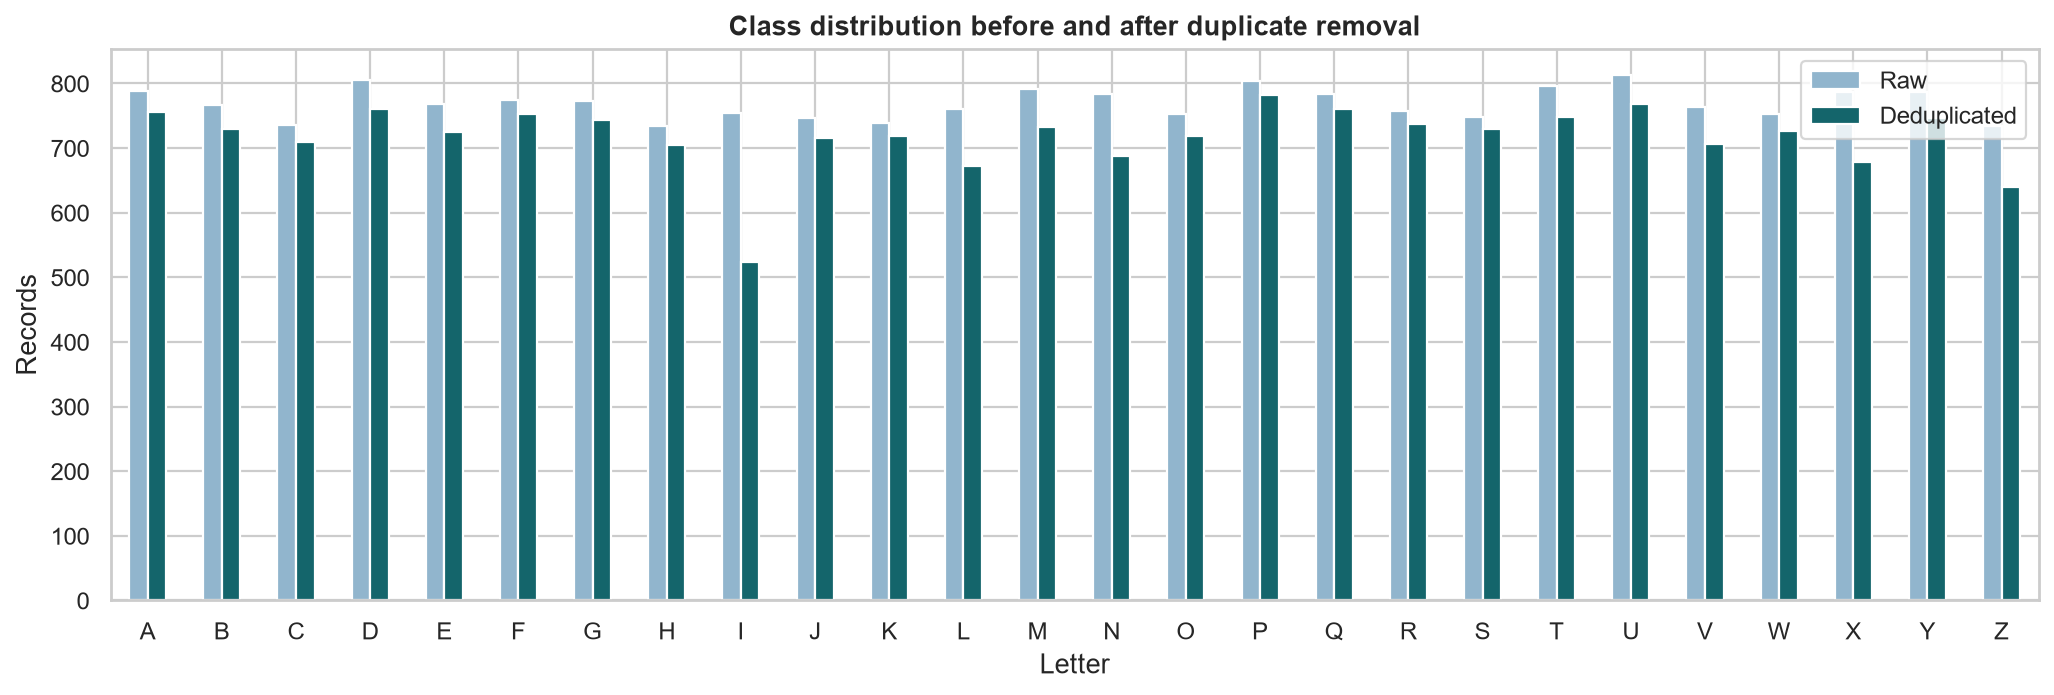

In [4]:
display(Image(filename=str(ROOT / "results/eda_visualizations/01_class_distribution.png")))

## Interpretation
All 20,000 records have complete, valid values. Removing 1,332 repeated records leaves 18,668. The chart shows how this changes each class frequency. Raw class counts range from 734 to 813; report cleaned counts when describing the final modeling dataset.

**Viva:** Why is a valid repeated vector not necessarily a copied image? Because the original descriptors were quantized. Why remove it before splitting? To prevent identical predictors appearing in training and evaluation.